# Congressional Bills Data Cleaning

This notebook creates the `*.csv` data files included in this repo. The code is based on the [replication code](https://osf.io/gjt87/) from Egami et al. (2023).

In [471]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Define directories
repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2"
os.chdir(repo_dir)

data_dir = os.path.join(repo_dir, "Data")
os.makedirs(data_dir, exist_ok=True)

codebooks_dir = os.path.join(data_dir, "Codebooks")
os.makedirs(codebooks_dir, exist_ok=True)

fig_dir = os.path.join(repo_dir, "Figures")
os.makedirs(fig_dir, exist_ok=True)

major_text_pap = {
    1 : "Macroeconomics",
    2 : "Civil Rights, Minority Issues, and Civil Liberties",
    3 : "Health",
    4 : "Agriculture",
    5 : "Labor and Employment",
    6 : "Education",
    7 : "Environment",
    8 : "Energy",
    9 : "Immigration",
    10: "Transportation",
    12: "Law, Crime, and Family Issues",
    13: "Social Welfare",
    14: "Community Development and Housing Issues",
    15: "Banking, Finance, and Domestic Commerce",
    16: "Defense",
    17: "Space, Science, Technology, and Communications",
    18: "Foreign Trade",
    19: "International Affairs and Foreign Aid",
    20: "Government Operations",
    21: "Public Lands and Water Management",
    23: "Arts and Entertainment",
    99: "Other, Miscellaneous, and Human Interest"
}

{1: 'Macroeconomics',
 2: 'Civil Rights, Minority Issues, and Civil Liberties',
 3: 'Health',
 4: 'Agriculture',
 5: 'Labor and Employment',
 6: 'Education',
 7: 'Environment',
 8: 'Energy',
 9: 'Immigration',
 10: 'Transportation',
 12: 'Law, Crime, and Family Issues',
 13: 'Social Welfare',
 14: 'Community Development and Housing Issues',
 15: 'Banking, Finance, and Domestic Commerce',
 16: 'Defense',
 17: 'Space, Science, Technology, and Communications',
 18: 'Foreign Trade',
 19: 'International Affairs and Foreign Aid',
 20: 'Government Operations',
 21: 'Public Lands and Water Management'}

## Load data from CAP

In [472]:
# Loaded CAP data
path_cap = "https://comparativeagendas.s3.amazonaws.com/datasetfiles/US-Legislative-congressional_bills_19.3_3_3.csv"
# path_cap = os.path.join(data_dir, "CAP.csv")
cap = pd.read_csv(path_cap, low_memory=False)

# Correct BillID
cap["BillID"] = cap["cong"].astype(str) + "-" + cap["bill_type"].apply(lambda x: x.upper()) + "-" + cap["bill_no"].astype(str) 

# Rename columns for consistency
cap.rename(columns={
    'majortopic': 'Major',
    'description': 'Description',
    'year': 'Year',
    'party': 'Party', 
    'pass_h': 'PassH', 
    'pass_s': 'PassS',
    'chamber': 'Chamber',
    'cong': 'Cong',
    'name_full': 'NameFull'}, inplace=True)

# Drop bills with missing data
cap.dropna(inplace=True, subset=['BillID', 'Year', 'Major', 'Description', 'Party', 'PassH', 'PassS', 'Chamber'])

# Remove duplicates based on bill ID and Description
cap.drop_duplicates(subset=["BillID", "Description"], inplace=True)

# Remove observations with Major=99 (~80,000)
cap = cap[cap["Major"]!=99]

# Correct chamber encoding for the 114th congress
if ~((cap.loc[cap["Cong"]==114,"Chamber"].unique()) == [1,2]).all():
    cap.loc[cap["Cong"]==114,"Chamber"] = cap.loc[cap["Cong"]==114,"Chamber"] + 1
cap["Chamber"] = cap["Chamber"].apply(lambda x: int(x == 2)) # House = 1, Senate = 2 in CAP

# Recode Party 400 as Democratic (100) 
cap.loc[(cap["Party"]==400) & (cap["NameFull"]=="Anibal Acevedo-Vila"), "Party"] = 100

# Make Major, PassH and PassS integers
cap['Major']  = cap['Major'].apply(lambda x: int(x))
cap['PassH']  = cap['PassH'].apply(lambda x: int(x))
cap['PassS']  = cap['PassS'].apply(lambda x: int(x))

# Keep columns we use
cap = cap[['BillID', 'Year', 'Major', 'Description', 'Party', 'PassH', 'PassS', 'Chamber']]

,BillID,Year,Major,Description,Party,PassH,PassS,Chamber
0,80-S-1873,1947,1,"A bill to maintain prosperity, promote full em...",200.0,0,0,1
1,80-HR-3000,1947,1,To amend the Employment Act of1946 so as to pr...,200.0,0,0,0
2,80-HR-4743,1947,1,"To maintain prosperity, to promote full employ...",200.0,0,0,0
3,80-S-525,1947,1,A bill to promote the progress of science and ...,100.0,0,0,1
4,80-HR-1815,1947,1,To promote the progress of science; to advance...,200.0,0,0,0


## Load variables from CBP

In [473]:
# cbp_80_92 = pd.read_csv("http://congressionalbills.org/billfiles/bills80-92.zip", sep='\t', encoding='latin-1')
cbp_80_92 = pd.read_csv(os.path.join(bills_dir, "CBP80-92.txt"), sep='\t', encoding='latin-1', low_memory=False)
cbp_80_92.rename(columns={' ': 'Minor'}, inplace=True)
cbp_80_92.drop(columns=['id', 'ByReq', 'Commem', 'oldMajor', 'oldMinor', 'Month', 'ReferArr', 'Year', 'Age', 'ComMArr', 'DW2', 'LeadCham', 'LeadComm', 'LeadSubC'], inplace=True)
cbp_80_92["DW1"] = cbp_80_92["DW1"].apply(lambda x: np.nan if x == -99.0 else x)

# cbp_93_114 = pd.read_csv("http://congressionalbills.org/billfiles/bills93-114.zip", sep=';', encoding='latin-1')
cbp_93_114 = pd.read_csv(os.path.join(bills_dir, "CBP93-114.csv"), sep=';', encoding='latin-1')
cbp_93_114.drop(columns='ImpBill', inplace=True)
cbp_93_114["DW1"] = cbp_93_114["DW1"].apply(lambda s: float(s.replace(",", ".") if isinstance(s, str) else s))

# Combine CBP datasets
cbp = pd.concat([cbp_80_92, cbp_93_114]).reset_index()
cbp.drop(columns='index', inplace=True)

# Correct BillID
cbp["BillType"] = cbp["BillType"].apply(lambda x: x.upper())
cbp["BillID"] = cbp["Cong"].astype(str) + "-" + cbp["BillType"] + "-" + cbp["BillNum"].astype(str) 

# Rename columns
cbp.rename(columns={'Title': 'Description'}, inplace=True)

# Drop bills with missing data
cbp.dropna(inplace=True, subset=['BillID', 'Major', 'Description', 'Party', 'PassH', 'PassS', 'Chamber'])

# Impute missing DW1 scores
cbp["DW1_NA"] = cbp["DW1"]
dw1 = cbp.groupby(["NameFull","DW1"], group_keys=True).first()["DW1_NA"] # Egami averages over bills. We average over unique members. Currently a unique member is identified by their full name and dw1 score.
dw1_mean = dw1.mean()
cbp.fillna(value={"DW1": dw1_mean}, inplace=True)

# Select columns
cbp = cbp[['BillID', 'Major', 'Description', 'Party', 'PassH', 'PassS', 'Chamber', 'DW1_NA', 'DW1', 'Postal']]

# Make Major, PassH and PassS integers
cbp['Major'] = cbp['Major'].apply(lambda x: int(x))

,BillID,Major,Description,Party,PassH,PassS,Chamber,DW1_NA,DW1,Postal
0,80-HR-1,1.0,To reduce individual income tax payments,200.0,1,1,0,0.533,0.533,MN
1,80-HR-2,16.0,To amend the Armed Forces Leave Act of 1946 by...,200.0,0,0,0,0.224,0.224,PA
2,80-HR-3,16.0,To amend the Armed Forces Leave Act of 1946 to...,100.0,0,0,0,0.003,0.003,FL
3,80-HR-4,12.0,To safeguard the admission of evidence in cert...,100.0,1,0,0,-0.125,-0.125,AL
4,80-HR-5,16.0,To protect honorably discharged veterans in th...,100.0,0,0,0,0.226,0.226,MS


## Merge CAP and CBP

In [474]:
# Merge CAP and CBP datasets
bills = cap.merge(cbp, on=["BillID", "Major", "Party", "PassS", "PassH", "Chamber"], suffixes=("", "_CBP"))

# Add MajorText column 
bills["MajorText"] = bills["Major"].apply(lambda x: major_text_pap[x])

# Recode major topic IDs (1,...,10,12,...,21,23) to (1,...,10,11,...,20,21)
major_pap = bills[['Major', 'MajorText']].drop_duplicates().reset_index()

major_pap2ours = {} 
for i in range(len(major_pap)): 
    dict_key = major_pap.loc[i, 'Major']
    dict_val = i+1
    major_pap2ours[dict_key] = dict_val
bills["Major"] = bills["Major"].apply(lambda x: major_pap2ours[x])

majors = bills[['Major', 'MajorText']].drop_duplicates().reset_index()
majors.to_csv(os.path.join(codebooks_dir, "major_topics.csv"))
print(f"major_topics.csv codebook saved at {codebooks_dir}") 

chamber_code = {0: "House", 1: "Senate", }
bills["Chamber"] = bills["Chamber"].apply(lambda x: chamber_code[x])

party_code = {
    100: "Democrat", 
    112: "Conservative",
    200: "Republican",
    328: "Independent"
}
bills["Party"] = bills["Party"].apply(lambda x: party_code[x])

,BillID,Year,Major,Description,Party,PassH,PassS,Chamber,Description_CBP,DW1_NA,DW1,Postal,MajorText
0,80-S-1873,1947,1,"A bill to maintain prosperity, promote full em...",200.0,0,0,1,"A bill to maintain prosperity, promote full em...",NaN,0.000148,IN,Macroeconomics
1,80-HR-3000,1947,1,To amend the Employment Act of1946 so as to pr...,200.0,0,0,0,To amend the Employment Act of1946 so as to pr...,0.750,0.750000,MI,Macroeconomics
2,80-HR-4743,1947,1,"To maintain prosperity, to promote full employ...",200.0,0,0,0,"To maintain prosperity, to promote full employ...",0.544,0.544000,IN,Macroeconomics
3,80-S-525,1947,1,A bill to promote the progress of science and ...,100.0,0,0,1,A bill to promote the progress of science and ...,NaN,0.000148,UT,Macroeconomics
4,80-HR-1815,1947,1,To promote the progress of science; to advance...,200.0,0,0,0,To promote the progress of science; to advance...,0.095,0.095000,NJ,Macroeconomics


In [475]:
from copy import deepcopy

def description_mismatch(d1, d2):
    description_cap = pd.Series(deepcopy(d1))
    description_cbp = pd.Series(deepcopy(d2))
    
    description_cbp = description_cbp.apply(lambda x: x.lower())
    description_cap = description_cap.apply(lambda x: x.lower())
    description_cbp = description_cbp.str.replace('??????', '')
    description_cbp = description_cbp.str.replace('???', '')
    description_cbp = description_cbp.str.replace('""""', '')
    description_cap = description_cap.str.replace('_??', '')
    description_cap = description_cap.str.replace('""""', '')
    description_cbp = description_cbp.str.replace('`', '')
    description_cbp = description_cbp.str.replace("'s", "s") 
    description_cap = description_cap.str.replace('`', '')
    description_cap = description_cap.str.replace("'s", "s") 

    condition = description_cap!=description_cbp
    description_cbp[condition] = description_cbp[condition].str.replace('\' ', ' ')

    condition = description_cap!=description_cbp
    description_cbp[condition] = description_cbp[condition].str.replace(' \'', ' ')

    condition = description_cap!=description_cbp
    description_cap[condition] = description_cap[condition].str.replace('\' ', ' ')

    condition = description_cap!=description_cbp
    description_cap[condition] = description_cap[condition] .str.replace(' \'', ' ')
    
    condition = (description_cap!=description_cbp) & (description_cap.apply(lambda x: x[:6]=="A bill")) & (description_cbp.apply(lambda x: x[:6]=="An Act"))
    description_cbp[condition] = description_cbp[condition].str.replace("An Act", "A bill", n=1) # around 1000 of those are different in how they start: "A bill" vs "An Act"
    
    condition = description_cap != description_cbp
    description_cap[condition] = description_cap[condition].str.replace("'", "")
    
    condition = description_cap!=description_cbp
    return condition

# Drop bills with mismatching Description
condition = description_mismatch(bills["Description"], bills["Description_CBP"])
bills = bills[~condition] 
bills.drop(columns="Description_CBP", inplace=True)

# Remove duplicates based Description
bills["Description_lower"] = bills["Description"].apply(lambda x: x.lower())
bills.drop_duplicates(subset='Description_lower', inplace=True)
bills.drop(columns="Description_lower", inplace=True)

major_topics.csv codebook saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Data/Codebooks


In [477]:
# Rearrange columns
bills = bills[['BillID', 'Year', 'Major', 'MajorText', 'Party', 'PassH', 'PassS', 'Description', 'DW1', 'DW1_NA', 'Chamber', 'Postal']]
bills.reset_index(inplace=True)

# Display the first few rows of cleaned data
bills.head()

,index,BillID,Year,Major,MajorText,Party,PassH,PassS,Description,DW1,DW1_NA,Chamber,Postal
0,0,80-S-1873,1947,1,Macroeconomics,Republican,0,0,"A bill to maintain prosperity, promote full em...",0.000148,NaN,Senate,IN
1,1,80-HR-3000,1947,1,Macroeconomics,Republican,0,0,To amend the Employment Act of1946 so as to pr...,0.750000,0.750,House,MI
2,2,80-HR-4743,1947,1,Macroeconomics,Republican,0,0,"To maintain prosperity, to promote full employ...",0.544000,0.544,House,IN
3,3,80-S-525,1947,1,Macroeconomics,Democrat,0,0,A bill to promote the progress of science and ...,0.000148,NaN,Senate,UT
4,4,80-HR-1815,1947,1,Macroeconomics,Republican,0,0,To promote the progress of science; to advance...,0.095000,0.095,House,NJ


## Sample 10K bills + generate 3 sets of 5 sample bills

In [478]:
seed = 123
n_examples = 5
# Bills used for few-shot prompting
examples = bills.groupby("Major").sample(n=1, random_state=seed).reset_index(drop=True)[:(n_examples*3)] # replace is False by default
# examples["Set"] = np.repeat([1, 2, 3], repeats=5)
# examples.to_csv(os.path.join(bills_dir, "bills_15.csv"), index=False)
examples01 = examples.iloc[:n_examples]
examples02 = examples.iloc[n_examples:(n_examples*2)]
examples03 = examples.iloc[(n_examples*2):]
examples01.to_csv(os.path.join(bills_dir, "bills_example1.csv"), index=False)
examples02.to_csv(os.path.join(bills_dir, "bills_example2.csv"), index=False)
examples03.to_csv(os.path.join(bills_dir, "bills_example3.csv"), index=False)

condition = bills["BillID"].apply(lambda x: x not in examples["BillID"].to_list())
bills_without_examples = bills[condition]
print(f"Removing {len(examples)} examples from bills data ...")
# bills_without_examples.to_csv(os.path.join(bills_dir, "bills_without_examples.csv"), index=False)
# print(f"bills_without_examples.csv, n = {len(bills_without_examples)}, saved at {bills_dir}")

bills_without_examples_10000 = bills_without_examples.sample(n=10_000, random_state=seed)
bills_without_examples_10000.to_csv(os.path.join(bills_dir, "bills_10k.csv"), index=False)
print(f"bills_10k.csv, n = {len(bills_without_examples_10000)}, saved at {bills_dir}")


Removing 15 examples from bills data ...
bills_10k.csv, n = 10000, saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Data/01_bills


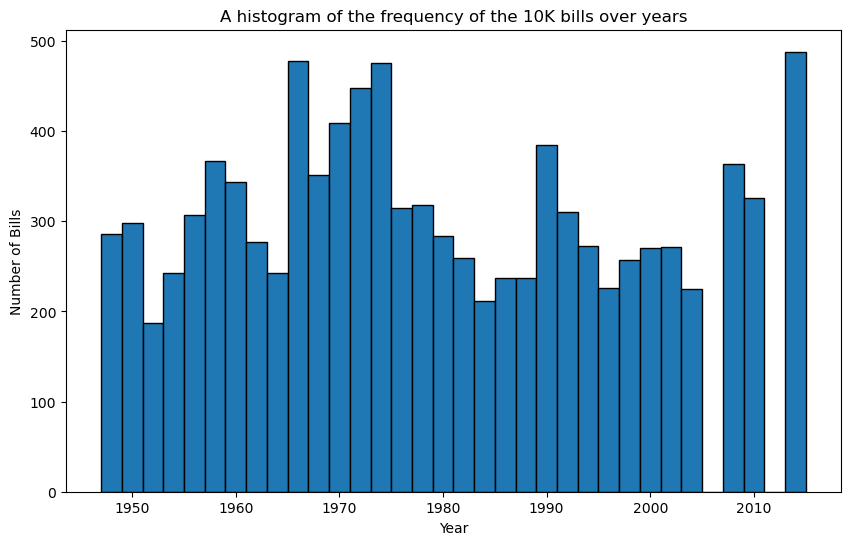

In [479]:
plt.figure(figsize=(10, 6))
bills_without_examples_10000['Year'].hist(bins=range(int(bills_without_examples_10000['Year'].min()), int(bills_without_examples_10000['Year'].max()) + 1, 2), edgecolor='black')
plt.title('A histogram of the frequency of the 10K bills over years')
plt.xlabel('Year')
plt.ylabel('Number of Bills')
plt.grid(False)
plt.savefig(os.path.join(fig_dir, 'A histogram of the frequency of the 10K bills over years.png'))